# MATH 5010 — Computer Lab 11: Sufficient Statistics

## Full solutions included

This lab supports **Section 11: Sufficient Statistics** in MATH 5010 Foundations of Statistical Theory & Probability.

### Main goals

By the end of this lab, students should be able to:

1. Explain the meaning of a sufficient statistic.
2. Use the factorization theorem to identify sufficient statistics.
3. Verify sufficiency by simulation for Bernoulli, Poisson, Exponential, Uniform, and Normal models.
4. Distinguish sufficient statistics from non-sufficient statistics.
5. Understand minimal sufficiency through likelihood-ratio comparisons.
6. See how sufficiency connects to estimator improvement through Rao--Blackwellization.

### Key idea

A statistic $T(X_1,\ldots,X_n)$ is **sufficient** for a parameter $\theta$ if, after we know $T$, the full sample contains no additional information about $\theta$.

A practical theorem used throughout this lab is the **Neyman--Fisher factorization theorem**:

$$
f_\theta(x_1,\ldots,x_n)=g_\theta(T(x_1,\ldots,x_n))h(x_1,\ldots,x_n).
$$

If the joint density or mass function factors in this way, then $T$ is sufficient for $\theta$.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb, factorial, exp, log, sqrt, pi

rng = np.random.default_rng(5010)

# Helper function for simple histogram plots
# We do not set custom colors so the notebook works well with default Matplotlib styles.
def hist_density(data, bins=30, title="", xlabel=""):
    plt.figure(figsize=(7, 4))
    plt.hist(data, bins=bins, density=True, alpha=0.75, edgecolor="black")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("density")
    plt.show()

## Part 1. Warm-up: What does sufficiency mean?

Suppose

$$
X_1,\ldots,X_n \overset{iid}{\sim}\operatorname{Bernoulli}(p).
$$

The joint probability mass function is

$$
P_p(X_1=x_1,\ldots,X_n=x_n)
=\prod_{i=1}^n p^{x_i}(1-p)^{1-x_i}.
$$

Let

$$
T=\sum_{i=1}^n X_i.
$$

### Exercise 1

Show that $T$ is sufficient for $p$.

### Full solution

We have

$$
\prod_{i=1}^n p^{x_i}(1-p)^{1-x_i}
= p^{\sum x_i}(1-p)^{n-\sum x_i}
= p^T(1-p)^{n-T}.
$$

This depends on the data only through $T=\sum X_i$. Thus

$$
g_p(T)=p^T(1-p)^{n-T},
\qquad
h(x_1,\ldots,x_n)=1.
$$

By the factorization theorem, $T=\sum X_i$ is sufficient for $p$.

Sample x = [1 0 1 1 0 0 1 0]
n = 8
T = sum(x) = 4
Are the full likelihood and T-based likelihood identical? True


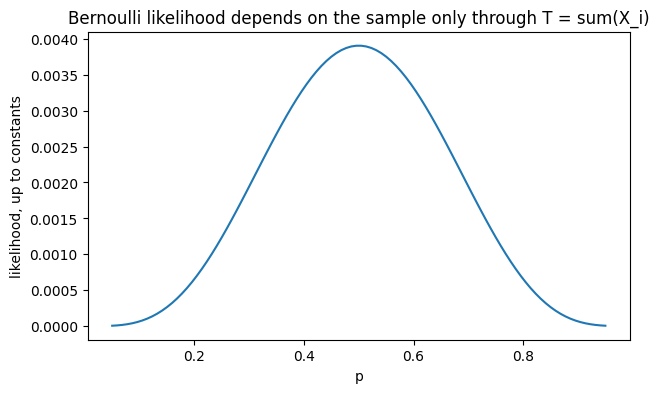

In [2]:
# Exercise 1: numerical verification for Bernoulli likelihood
x = np.array([1, 0, 1, 1, 0, 0, 1, 0])
n = len(x)
T = x.sum()

p_values = np.linspace(0.05, 0.95, 100)
likelihood_full = p_values**T * (1 - p_values)**(n - T)
likelihood_using_T = p_values**T * (1 - p_values)**(n - T)

print("Sample x =", x)
print("n =", n)
print("T = sum(x) =", T)
print("Are the full likelihood and T-based likelihood identical?", np.allclose(likelihood_full, likelihood_using_T))

plt.figure(figsize=(7, 4))
plt.plot(p_values, likelihood_full)
plt.title("Bernoulli likelihood depends on the sample only through T = sum(X_i)")
plt.xlabel("p")
plt.ylabel("likelihood, up to constants")
plt.show()

## Part 2. Conditional distribution given a sufficient statistic

A powerful way to understand sufficiency is conditional distribution.

If $T$ is sufficient for $\theta$, then the conditional distribution of the full sample given $T$ should not depend on $\theta$.

For Bernoulli data, if $T=s$, then exactly $s$ of the $n$ observations are equal to 1. Every binary vector with exactly $s$ ones has the same conditional probability:

$$
P_p(X=x\mid T=s)=\frac{1}{\binom{n}{s}},
$$

which does **not** depend on $p$.

### Exercise 2

For $n=8$ and $s=3$, enumerate all binary samples with exactly 3 ones and verify that the conditional probability is $1/\binom{8}{3}$ for every such sample.

### Full solution

There are

$$
\binom{8}{3}=56
$$

binary vectors with exactly three 1s. For any such vector $x$,

$$
P_p(X=x)=p^3(1-p)^5.
$$

Also

$$
P_p(T=3)=\binom{8}{3}p^3(1-p)^5.
$$

Therefore

$$
P_p(X=x\mid T=3)
=\frac{p^3(1-p)^5}{\binom{8}{3}p^3(1-p)^5}
=\frac{1}{\binom{8}{3}},
$$

which does not depend on $p$.

In [3]:
from itertools import combinations

n = 8
s = 3
patterns = []
for ones in combinations(range(n), s):
    arr = np.zeros(n, dtype=int)
    arr[list(ones)] = 1
    patterns.append(arr)

num_patterns = len(patterns)
conditional_prob = 1 / num_patterns

print("Number of binary vectors with exactly 3 ones:", num_patterns)
print("C(8,3) =", comb(8,3))
print("Conditional probability for each vector:", conditional_prob)
print("First five such vectors:")
for arr in patterns[:5]:
    print(arr)

# Verify independence from p for several values
for p in [0.2, 0.5, 0.8]:
    numerator = p**s * (1-p)**(n-s)
    denominator = comb(n, s) * p**s * (1-p)**(n-s)
    print(f"p = {p:.1f}, conditional probability = {numerator/denominator:.6f}")

Number of binary vectors with exactly 3 ones: 56
C(8,3) = 56
Conditional probability for each vector: 0.017857142857142856
First five such vectors:
[1 1 1 0 0 0 0 0]
[1 1 0 1 0 0 0 0]
[1 1 0 0 1 0 0 0]
[1 1 0 0 0 1 0 0]
[1 1 0 0 0 0 1 0]
p = 0.2, conditional probability = 0.017857
p = 0.5, conditional probability = 0.017857
p = 0.8, conditional probability = 0.017857


## Part 3. Poisson model

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Poisson}(\lambda).
$$

The joint pmf is

$$
P_\lambda(X_1=x_1,\ldots,X_n=x_n)
=\prod_{i=1}^n \frac{e^{-\lambda}\lambda^{x_i}}{x_i!}
= e^{-n\lambda}\lambda^{\sum x_i}\prod_{i=1}^n\frac{1}{x_i!}.
$$

### Exercise 3

Use the factorization theorem to find a sufficient statistic for $\lambda$.

### Full solution

The joint pmf can be written as

$$
P_\lambda(x_1,\ldots,x_n)
=\underbrace{e^{-n\lambda}\lambda^{\sum x_i}}_{g_\lambda(T)}
\underbrace{\prod_{i=1}^n\frac{1}{x_i!}}_{h(x_1,\ldots,x_n)}.
$$

Thus

$$
T=\sum_{i=1}^n X_i
$$

is sufficient for $\lambda$.

Also, since a sum of independent Poisson random variables is Poisson,

$$
T\sim \operatorname{Poisson}(n\lambda).
$$

First five conditional samples with total m=12:
[[2 0 6 4]
 [1 6 3 2]
 [4 2 4 2]
 [2 3 4 3]
 [4 1 4 3]]
All row sums equal 12? True
Empirical mean of each coordinate given total 12:
[3.00575 3.00455 2.9942  2.9955 ]
Theoretical conditional mean for each coordinate = m/n = 3.0


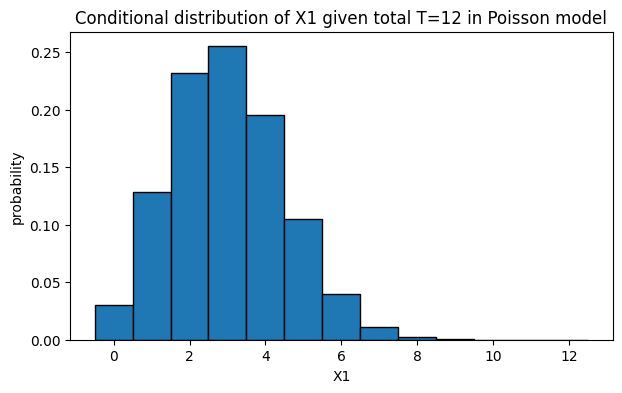

In [4]:
# Simulation: Poisson samples with the same total count have conditional structure not depending on lambda.
# Given T=m, the vector (X1,...,Xn) has a multinomial distribution with m trials and equal probabilities 1/n.

n = 4
m = 12
B = 20_000

# Direct conditional simulation from Multinomial(m, equal probabilities)
conditional_samples = rng.multinomial(m, [1/n]*n, size=B)

print("First five conditional samples with total m=12:")
print(conditional_samples[:5])
print("All row sums equal 12?", np.all(conditional_samples.sum(axis=1) == m))
print("Empirical mean of each coordinate given total 12:")
print(conditional_samples.mean(axis=0))
print("Theoretical conditional mean for each coordinate = m/n =", m/n)

plt.figure(figsize=(7, 4))
plt.hist(conditional_samples[:,0], bins=np.arange(-0.5, m+1.5, 1), density=True, edgecolor="black")
plt.title("Conditional distribution of X1 given total T=12 in Poisson model")
plt.xlabel("X1")
plt.ylabel("probability")
plt.show()

### Why the conditional distribution does not depend on $\lambda$

Given $T=m$, the conditional distribution is

$$
(X_1,\ldots,X_n)\mid T=m
\sim \operatorname{Multinomial}\left(m;\frac{1}{n},\ldots,\frac{1}{n}\right).
$$

This distribution does not contain $\lambda$. This agrees with the fact that $T=\sum X_i$ is sufficient.

## Part 4. Exponential model

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Exponential}(\lambda),
$$

where $\lambda$ is the rate parameter and

$$
f_\lambda(x)=\lambda e^{-\lambda x},\qquad x>0.
$$

### Exercise 4

Find a sufficient statistic for $\lambda$.

### Full solution

The joint density is

$$
f_\lambda(x_1,\ldots,x_n)
=\prod_{i=1}^n \lambda e^{-\lambda x_i}\mathbf{1}_{x_i>0}
=\lambda^n e^{-\lambda\sum x_i}\prod_{i=1}^n\mathbf{1}_{x_i>0}.
$$

Thus

$$
g_\lambda(T)=\lambda^n e^{-\lambda T},
\qquad T=\sum_{i=1}^n X_i,
$$

and

$$
h(x_1,\ldots,x_n)=\prod_{i=1}^n\mathbf{1}_{x_i>0}.
$$

By the factorization theorem,

$$
T=\sum_{i=1}^n X_i
$$

is sufficient for $\lambda$.

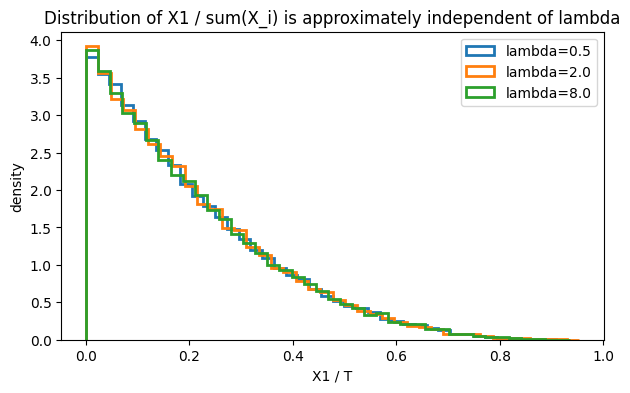

In [5]:
# Exponential model simulation: T=sum(X_i) is sufficient.
# The normalized proportions X_i / T do not depend on lambda.

n = 5
B = 50_000
lambda_values = [0.5, 2.0, 8.0]

plt.figure(figsize=(7, 4))
for lam in lambda_values:
    X = rng.exponential(scale=1/lam, size=(B, n))  # scale = 1/rate
    P1 = X[:, 0] / X.sum(axis=1)
    plt.hist(P1, bins=40, density=True, histtype="step", linewidth=2, label=f"lambda={lam}")

plt.title("Distribution of X1 / sum(X_i) is approximately independent of lambda")
plt.xlabel("X1 / T")
plt.ylabel("density")
plt.legend()
plt.show()

### Interpretation

The plot overlays the distribution of

$$
\frac{X_1}{\sum_{i=1}^n X_i}
$$

for different values of $\lambda$. The curves are approximately the same. This supports the idea that after conditioning on the sufficient statistic $T=\sum X_i$, the remaining shape of the sample no longer depends on $\lambda$.

## Part 5. Uniform model with unknown upper endpoint

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Uniform}(0,\theta),
\qquad \theta>0.
$$

The density of one observation is

$$
f_\theta(x)=\frac{1}{\theta}\mathbf{1}_{0<x<\theta}.
$$

### Exercise 5

Find a sufficient statistic for $\theta$.

### Full solution

The joint density is

$$
f_\theta(x_1,\ldots,x_n)
=\theta^{-n}\mathbf{1}_{0<x_1<\theta}\cdots\mathbf{1}_{0<x_n<\theta}.
$$

The condition $0<x_i<\theta$ for all $i$ is equivalent to

$$
0<x_{(1)} \quad \text{and} \quad x_{(n)}<\theta,
$$

where

$$
x_{(n)}=\max\{x_1,\ldots,x_n\}.
$$

Thus

$$
f_\theta(x_1,\ldots,x_n)
=\underbrace{\theta^{-n}\mathbf{1}_{x_{(n)}<\theta}}_{g_\theta(x_{(n)})}
\underbrace{\mathbf{1}_{x_{(1)}>0}}_{h(x_1,\ldots,x_n)}.
$$

Therefore

$$
T=X_{(n)}=\max\{X_1,\ldots,X_n\}
$$

is sufficient for $\theta$.

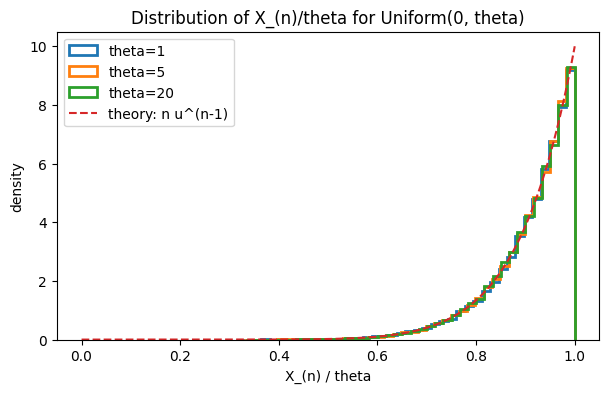

In [6]:
# Uniform(0, theta): the maximum is sufficient.
# We simulate the ratio X_(n)/theta. Its distribution should not depend on theta.

n = 10
B = 50_000
theta_values = [1, 5, 20]

plt.figure(figsize=(7, 4))
for theta in theta_values:
    X = rng.uniform(0, theta, size=(B, n))
    max_scaled = X.max(axis=1) / theta
    plt.hist(max_scaled, bins=40, density=True, histtype="step", linewidth=2, label=f"theta={theta}")

# Theoretical density of M/theta: n u^(n-1), 0<u<1
u = np.linspace(0, 1, 300)
plt.plot(u, n * u**(n-1), linestyle="--", label="theory: n u^(n-1)")
plt.title("Distribution of X_(n)/theta for Uniform(0, theta)")
plt.xlabel("X_(n) / theta")
plt.ylabel("density")
plt.legend()
plt.show()

### Solution note

For $M=X_{(n)}$, the CDF is

$$
P(M\le m)=\left(\frac{m}{\theta}\right)^n,
\qquad 0<m<\theta.
$$

Therefore

$$
\frac{M}{\theta}\quad \text{has CDF}\quad u^n,
\qquad 0<u<1,
$$

and density

$$
f(u)=nu^{n-1}.
$$

## Part 6. Normal model with known variance

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}N(\mu,\sigma^2),
$$

where $\sigma^2$ is known and $\mu$ is unknown.

### Exercise 6

Show that $\bar X$ is sufficient for $\mu$.

### Full solution

The joint density is

$$
f_\mu(x_1,\ldots,x_n)
=(2\pi\sigma^2)^{-n/2}
\exp\left[-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2\right].
$$

Expand the sum:

$$
\sum_{i=1}^n(x_i-\mu)^2
=\sum_{i=1}^n x_i^2-2\mu\sum_{i=1}^n x_i+n\mu^2.
$$

Therefore

$$
f_\mu(x_1,\ldots,x_n)
=(2\pi\sigma^2)^{-n/2}
\exp\left[-\frac{1}{2\sigma^2}\sum x_i^2\right]
\exp\left[\frac{\mu}{\sigma^2}\sum x_i-\frac{n\mu^2}{2\sigma^2}\right].
$$

The parameter-dependent part depends on the data only through $\sum X_i$, equivalently through $\bar X$. Hence $\bar X$ is sufficient for $\mu$.

x_a mean: 5.0 sum of squares: 120
x_b mean: 5.0 sum of squares: 116


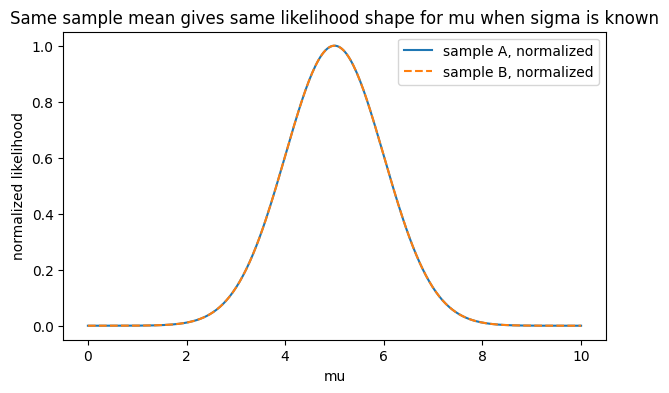

In [7]:
# Normal known variance: likelihood for mu depends on the sample only through the sample mean.

sigma = 2.0
x_a = np.array([2, 4, 6, 8])       # mean 5
x_b = np.array([3, 3, 7, 7])       # mean 5, different spread

print("x_a mean:", x_a.mean(), "sum of squares:", np.sum(x_a**2))
print("x_b mean:", x_b.mean(), "sum of squares:", np.sum(x_b**2))

mu_grid = np.linspace(0, 10, 300)

def normal_known_sigma_likelihood(x, mu_grid, sigma):
    n = len(x)
    # full likelihood, including constants
    return (1/(sqrt(2*pi)*sigma))**n * np.exp(-np.sum((x[:, None] - mu_grid[None, :])**2, axis=0)/(2*sigma**2))

L_a = normal_known_sigma_likelihood(x_a, mu_grid, sigma)
L_b = normal_known_sigma_likelihood(x_b, mu_grid, sigma)

# Normalize to compare shapes.
L_a_norm = L_a / L_a.max()
L_b_norm = L_b / L_b.max()

plt.figure(figsize=(7, 4))
plt.plot(mu_grid, L_a_norm, label="sample A, normalized")
plt.plot(mu_grid, L_b_norm, linestyle="--", label="sample B, normalized")
plt.title("Same sample mean gives same likelihood shape for mu when sigma is known")
plt.xlabel("mu")
plt.ylabel("normalized likelihood")
plt.legend()
plt.show()

### Interpretation

The two samples have the same mean but different spreads. When $\sigma$ is known, the likelihood as a function of $\mu$ has the same shape after normalization. This illustrates that the sample mean contains all information about $\mu$ in the normal model with known variance.

## Part 7. A non-example: sample mean alone is not sufficient when both $\mu$ and $\sigma^2$ are unknown

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}N(\mu,\sigma^2),
$$

where both $\mu$ and $\sigma^2$ are unknown.

### Exercise 7

Find a sufficient statistic for $(\mu,\sigma^2)$ and explain why $\bar X$ alone is not sufficient.

### Full solution

The joint density is

$$
f_{\mu,\sigma^2}(x_1,\ldots,x_n)
=(2\pi\sigma^2)^{-n/2}
\exp\left[-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2\right].
$$

Expanding,

$$
\sum_{i=1}^n(x_i-\mu)^2
=\sum x_i^2-2\mu\sum x_i+n\mu^2.
$$

Thus the density depends on the data through both

$$
\sum X_i
\quad \text{and} \quad
\sum X_i^2.
$$

Therefore

$$
T=\left(\sum_{i=1}^n X_i,\sum_{i=1}^n X_i^2\right)
$$

is sufficient for $(\mu,\sigma^2)$.

The sample mean $\bar X$ alone is not sufficient because it does not determine $\sum X_i^2$, which affects the likelihood when $\sigma^2$ is unknown.

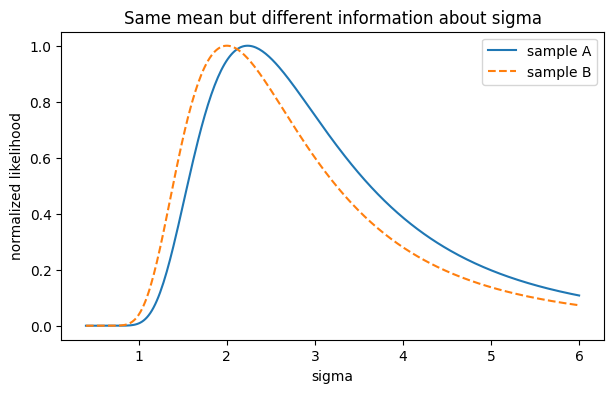

Sample A mean: 5.0 sum squares: 120 sum centered squares: 20.0
Sample B mean: 5.0 sum squares: 116 sum centered squares: 16.0


In [8]:
# Demonstrate that same mean but different sum of squares gives different likelihood in sigma.

x_a = np.array([2, 4, 6, 8])       # mean 5, larger spread
x_b = np.array([3, 3, 7, 7])       # mean 5, smaller spread
mu_fixed = 5.0
sigma_grid = np.linspace(0.4, 6, 300)

def normal_likelihood_sigma(x, mu, sigma_grid):
    n = len(x)
    return (1/(np.sqrt(2*np.pi)*sigma_grid))**n * np.exp(-np.sum((x - mu)**2)/(2*sigma_grid**2))

L_a_sigma = normal_likelihood_sigma(x_a, mu_fixed, sigma_grid)
L_b_sigma = normal_likelihood_sigma(x_b, mu_fixed, sigma_grid)

plt.figure(figsize=(7, 4))
plt.plot(sigma_grid, L_a_sigma / L_a_sigma.max(), label="sample A")
plt.plot(sigma_grid, L_b_sigma / L_b_sigma.max(), linestyle="--", label="sample B")
plt.title("Same mean but different information about sigma")
plt.xlabel("sigma")
plt.ylabel("normalized likelihood")
plt.legend()
plt.show()

print("Sample A mean:", x_a.mean(), "sum squares:", np.sum(x_a**2), "sum centered squares:", np.sum((x_a-mu_fixed)**2))
print("Sample B mean:", x_b.mean(), "sum squares:", np.sum(x_b**2), "sum centered squares:", np.sum((x_b-mu_fixed)**2))

## Part 8. Minimal sufficiency through likelihood ratios

A statistic $T$ is often minimal sufficient if it is the most compressed sufficient statistic.

One useful criterion is:

For a dominated family, $T$ is minimal sufficient if

$$
\frac{f_\theta(x)}{f_\theta(y)}
$$

is free of $\theta$ exactly when $T(x)=T(y)$.

### Exercise 8

For the exponential rate model

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Exponential}(\lambda),
$$

show that $T=\sum X_i$ is minimal sufficient.

### Full solution

The joint density is

$$
f_\lambda(x)=\lambda^n e^{-\lambda\sum x_i}\prod_{i=1}^n\mathbf{1}_{x_i>0}.
$$

For two samples $x=(x_1,\ldots,x_n)$ and $y=(y_1,\ldots,y_n)$ in the support,

$$
\frac{f_\lambda(x)}{f_\lambda(y)}
=\frac{\lambda^n e^{-\lambda\sum x_i}}{\lambda^n e^{-\lambda\sum y_i}}
=\exp\left[-\lambda\left(\sum x_i-\sum y_i\right)\right].
$$

This ratio is free of $\lambda$ if and only if

$$
\sum x_i=\sum y_i.
$$

Therefore $T=\sum X_i$ is minimal sufficient.

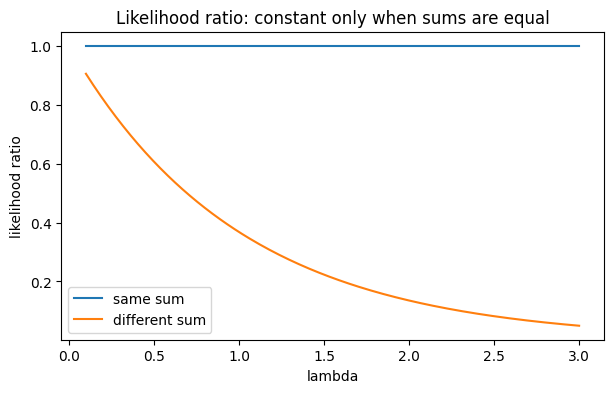

sum(x) = 6.0
sum(y_same_sum) = 6.0
sum(y_diff_sum) = 5.0


In [9]:
# Numerical illustration of the likelihood ratio criterion for Exponential(lambda)

x = np.array([1.0, 2.0, 3.0])  # sum = 6
# y_same_sum has the same total
# y_diff_sum has a different total
y_same_sum = np.array([0.5, 2.5, 3.0])  # sum = 6
y_diff_sum = np.array([1.0, 1.0, 3.0])  # sum = 5

lambda_grid = np.linspace(0.1, 3, 200)

def exp_rate_likelihood(sample, lam):
    n = len(sample)
    return lam**n * np.exp(-lam * sample.sum())

ratio_same = exp_rate_likelihood(x, lambda_grid) / exp_rate_likelihood(y_same_sum, lambda_grid)
ratio_diff = exp_rate_likelihood(x, lambda_grid) / exp_rate_likelihood(y_diff_sum, lambda_grid)

plt.figure(figsize=(7, 4))
plt.plot(lambda_grid, ratio_same, label="same sum")
plt.plot(lambda_grid, ratio_diff, label="different sum")
plt.title("Likelihood ratio: constant only when sums are equal")
plt.xlabel("lambda")
plt.ylabel("likelihood ratio")
plt.legend()
plt.show()

print("sum(x) =", x.sum())
print("sum(y_same_sum) =", y_same_sum.sum())
print("sum(y_diff_sum) =", y_diff_sum.sum())

## Part 9. Rao--Blackwell improvement using a sufficient statistic

Sufficiency is not only a theoretical idea. It can improve estimators.

Suppose

$$
X_1,\ldots,X_n\overset{iid}{\sim}\operatorname{Bernoulli}(p).
$$

A simple unbiased estimator of $p$ is

$$
\delta(X)=X_1.
$$

Since $T=\sum X_i$ is sufficient for $p$, the Rao--Blackwell improved estimator is

$$
\delta^*(T)=E[X_1\mid T].
$$

### Exercise 9

Compute $E[X_1\mid T]$ and compare the variance of $X_1$ with the variance of $T/n$.

### Full solution

Given $T=s$, exactly $s$ of the $n$ observations are 1. By symmetry, the probability that $X_1=1$ is $s/n$. Therefore

$$
E[X_1\mid T=s]=\frac{s}{n}.
$$

Thus

$$
E[X_1\mid T]=\frac{T}{n}=\bar X.
$$

Both $X_1$ and $\bar X$ are unbiased for $p$:

$$
E[X_1]=p,
\qquad
E[\bar X]=p.
$$

But their variances are

$$
\operatorname{Var}(X_1)=p(1-p),
$$

and

$$
\operatorname{Var}(\bar X)=\frac{p(1-p)}{n}.
$$

For $n>1$, $\bar X$ has smaller variance. This is exactly the Rao--Blackwell improvement.

In [10]:
# Simulation: Rao-Blackwellization for Bernoulli(p)

p = 0.35
n = 20
B = 100_000
X = rng.binomial(1, p, size=(B, n))

estimator_x1 = X[:, 0]
estimator_rb = X.mean(axis=1)  # T/n

summary = pd.DataFrame({
    "Estimator": ["X1", "T/n = sample mean"],
    "Empirical mean": [estimator_x1.mean(), estimator_rb.mean()],
    "Empirical variance": [estimator_x1.var(ddof=0), estimator_rb.var(ddof=0)],
    "Theoretical variance": [p*(1-p), p*(1-p)/n]
})

summary

,Estimator,Empirical mean,Empirical variance,Theoretical variance
0,X1,0.348410,0.227020,0.227500
1,T/n = sample mean,0.349668,0.011355,0.011375


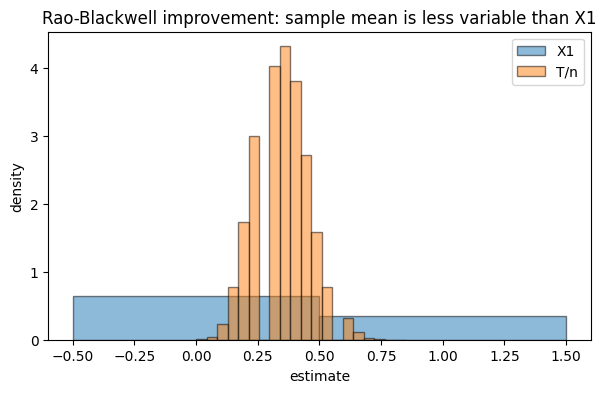

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(estimator_x1, bins=np.array([-0.5, 0.5, 1.5]), density=True, alpha=0.5, edgecolor="black", label="X1")
plt.hist(estimator_rb, bins=20, density=True, alpha=0.5, edgecolor="black", label="T/n")
plt.title("Rao-Blackwell improvement: sample mean is less variable than X1")
plt.xlabel("estimate")
plt.ylabel("density")
plt.legend()
plt.show()

## Part 10. Summary table

| Model | Unknown parameter | Joint distribution depends on data through | Sufficient statistic |
|---|---:|---:|---:|
| Bernoulli$(p)$ | $p$ | $\sum X_i$ | $\sum X_i$ |
| Binomial$(m,p)$ with fixed $m$ | $p$ | $\sum X_i$ | $\sum X_i$ |
| Poisson$(\lambda)$ | $\lambda$ | $\sum X_i$ | $\sum X_i$ |
| Exponential rate $\lambda$ | $\lambda$ | $\sum X_i$ | $\sum X_i$ |
| Exponential mean $\theta$ | $\theta$ | $\sum X_i$ | $\sum X_i$ |
| Uniform$(0,\theta)$ | $\theta$ | $X_{(n)}$ | $X_{(n)}$ |
| Normal$(\mu,\sigma^2)$, known $\sigma^2$ | $\mu$ | $\sum X_i$ | $\bar X$ or $\sum X_i$ |
| Normal$(\mu,\sigma^2)$, both unknown | $(\mu,\sigma^2)$ | $(\sum X_i,\sum X_i^2)$ | $(\sum X_i,\sum X_i^2)$ |

## Final reflection questions with answers

### Question A
Why is the full data often more than we need for inference about a parameter?

**Answer.** In many parametric models, the likelihood depends on the full data only through a lower-dimensional statistic. Once that statistic is known, the remaining details of the sample have no additional information about the parameter.

### Question B
Why is $\sum X_i$ sufficient for many models?

**Answer.** Many common models are exponential-family models. Their likelihood often has a term of the form

$$
\exp\{\eta(\theta)\sum X_i\},
$$

so the data enter the parameter-dependent part only through $\sum X_i$.

### Question C
What is the difference between sufficient and minimal sufficient?

**Answer.** A sufficient statistic contains all information in the sample about the parameter. A minimal sufficient statistic is the most compressed statistic with this property. Every sufficient statistic must contain at least as much information as the minimal sufficient statistic.

### Question D
How does sufficiency connect to estimator improvement?

**Answer.** If $T$ is sufficient and $\delta(X)$ is an estimator, then $E[\delta(X)\mid T]$ is a function of the sufficient statistic. Under squared error loss, it has no larger mean squared error than the original estimator. This is the Rao--Blackwell theorem.

## Optional challenge: write your own factorization proof

For each model below, find a sufficient statistic using the factorization theorem.

1. $X_1,\ldots,X_n\sim\operatorname{Geometric}(p)$ with $P(X=x)=p(1-p)^{x-1}$, $x=1,2,\ldots$.
2. $X_1,\ldots,X_n\sim\operatorname{Gamma}(\alpha,\beta)$ with known $\alpha$ and unknown rate $\beta$.
3. $X_1,\ldots,X_n\sim\operatorname{Normal}(0,\sigma^2)$ with unknown $\sigma^2$.

### Full solutions

1. Geometric:

$$
L(p)=\prod_{i=1}^n p(1-p)^{x_i-1}
=p^n(1-p)^{\sum x_i-n}.
$$

So $T=\sum X_i$ is sufficient for $p$.

2. Gamma with known shape $\alpha$ and unknown rate $\beta$:

$$
f_\beta(x)=\frac{\beta^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}.
$$

The joint density is

$$
L(\beta)=\left(\frac{\beta^\alpha}{\Gamma(\alpha)}\right)^n
\left(\prod x_i^{\alpha-1}\right)e^{-\beta\sum x_i}.
$$

Thus $T=\sum X_i$ is sufficient for $\beta$.

3. Normal with mean 0 and unknown variance $\sigma^2$:

$$
L(\sigma^2)=(2\pi\sigma^2)^{-n/2}
\exp\left[-\frac{1}{2\sigma^2}\sum x_i^2\right].
$$

Thus

$$
T=\sum X_i^2
$$

is sufficient for $\sigma^2$.